In [1]:
import os
import math
import random
import re
from collections import defaultdict
import matplotlib.pyplot as plt

labels_location = os.path.join('./trec06p-ai201', 'labels')

In [2]:
# 1. Functions for retrieving training and test data
def get_data_paths(labels_location):
    # Returns the data paths where location is first then the label 
    data = []

    if not os.path.exists(labels_location): # error checking
        print(f"Error: labels not found at {labels_location}")
        return []

    base_directory = os.path.dirname(labels_location) # finds the base directory of the labels

    with open(labels_location, 'r', encoding='utf-8', errors='ignore') as file: # opens the labels file (read-only, utf-8 and ignore errors)
        for each_line in file:
            parts = each_line.strip().split() # removes /n and converts into a list by splitting
            if len(parts) == 2:
                label = parts[0]
                associated_path = parts[1]

                path_option1 = os.path.normpath(os.path.join(base_directory, associated_path)) # Adjusts the formatting to be compatible with both Windows and MacOS

                clean_associated_path = associated_path.replace('../', '')
                path_option2 = os.path.normpath(os.path.join(base_directory, clean_associated_path)) # Alternative method if path_option1 results in error

                if os.path.exists(path_option1): # adds the data paths to the list
                    data.append((path_option1, label))
                elif os.path.exists(path_option2):
                    data.append((path_option2, label))
                else:
                    if len(data) == 0:
                        print(f"Error: Could not find file at:{path_option1}or{path_option2}")

    if len(data) == 0:
        print("No data files were found.")

    return data

def parse_document(filepath):
    # Opens the emails based on the filepath and filters the words according to the requirements.
    unique_words_in_doc = set() # variable that will contain every unique word in the email

    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as file: # Ensures that the email complies  
            content = file.read().replace('\n', ' ') # Replaces /n with space
            potential_word = content.split(' ') 

            for chunk in potential_word:
                # When a word is None, skip the word and continue the for loop
                if not chunk:
                    continue

                clean_word = None

                match = re.match(r'^([a-zA-Z]+)([,.]?)$', chunk) # Filters the word where using Regex library
                if match:
                    clean_word = match.group(1) # Retrieves the word after filtering
                if clean_word:
                    unique_words_in_doc.add(clean_word) # Adds the word into the set

    except Exception as e: # Exception handling for errors on try block
        pass

    return unique_words_in_doc

In [3]:
# 2. The Naive Bayes Classifier Class

class NaiveBayesClassifier:
    def __init__(self, lamb=1.0):
        # contains the default count statistics
        self.lamb = lamb  # Lambda smoothing parameter
        self.vocab = set() # contains a set of unique word
        self.spam_doc_count = 0 # Number of documents that are spam
        self.ham_doc_count = 0 # Number of documents that are ham
        self.spam_word_counts = defaultdict(int)  # Number word in spam
        self.ham_word_counts = defaultdict(int)  # Number word in ham
        self.p_spam = 0.0
        self.p_ham = 0.0
        self.selected_features = None

    def train(self, training_set):
        # Prepares the values needed for class conditional likelihood with lambda smoothing formula and Naive Bayes Classifier

        print(f"Training on {len(training_set)} documents...")

        # Resets the count statistics per training
        self.vocab = set()
        self.spam_doc_count = 0
        self.ham_doc_count = 0
        self.spam_word_counts.clear()
        self.ham_word_counts.clear()

        for filepath, label in training_set:

        # Indicator Function
            words = parse_document(filepath) # Calls the parse_document function to return variable as a set of unique words
            self.vocab.update(words)

            if label == 'spam':
                self.spam_doc_count += 1 # Updates the counter for the total number of spam
                for word in words:
                    self.spam_word_counts[word] += 1 # Summation of per unique word in spam
            else:
                self.ham_doc_count += 1 # Updates the counter for the total number of ham (Cardinality)
                for word in words:
                    self.ham_word_counts[word] += 1 # Summation of per unique word in ham

        #  Form the vocabulary V of unique words in the training data, count their statistics
        # and report the prior probabilities for spam and ham.
        total_docs = self.spam_doc_count + self.ham_doc_count
        self.p_spam = self.spam_doc_count / total_docs
        self.p_ham = self.ham_doc_count / total_docs

        print(f"Training Complete. Vocab Size: {len(self.vocab)}")
        print(f"Prior Spam: {self.p_spam:.4f}, Prior Ham: {self.p_ham:.4f}")

    def get_word_percentage(self, word, label):
        # Retrieves the probability of a word (P(xi|ω)) using class conditional likelihood with Lambda Smoothing

        if label == 'spam':
            count_docs_with_word = self.spam_word_counts.get(word, 0) # Retrieves the number of times a unique word appeared across all spam
            count_total_docs = self.spam_doc_count # Retrieves the total number of spam emails
        else:
            count_docs_with_word = self.ham_word_counts.get(word, 0) # Retrieves the number of times a unique word appeared across all ham
            count_total_docs = self.ham_doc_count # Retrieves the total number of ham emails

        if self.selected_features is not None:
            vocab_size = len(self.selected_features)
        else:
            vocab_size = len(self.vocab)

        numerator = count_docs_with_word + self.lamb # Summation from train and adds the lambda
        denominator = count_total_docs + (self.lamb * vocab_size) # Cardinality plus Lambda times with total vocab size

        return numerator / denominator # percentage of word likelihood

    def classify(self, filepath):
        #  Construct and train a Naive Bayesian Classifier from the count statistics above.

        words = parse_document(filepath)

        # Uses Logarithm instead of multiplication of probabilities to prevent rounding to 0
        # Converts the probabilities into "log score"
        if self.p_spam > 0:
            log_prob_spam = math.log(self.p_spam)
        else:
            log_prob_spam = -float('inf') # prevents log(0)

        if self.p_ham > 0:
            log_prob_ham = math.log(self.p_ham)
        else:
            log_prob_ham = -float('inf') # prevents log(0)

        if self.selected_features: # determines whether to use hovold's mutual informaiton or whole vocabulary size
            features_to_check = self.selected_features
        else:
            features_to_check = self.vocab
            
        for word in words:
            if word in features_to_check:
                p_w_spam = self.get_word_percentage(word, 'spam')
                log_prob_spam += math.log(p_w_spam)

                p_w_ham = self.get_word_percentage(word, 'ham')
                log_prob_ham += math.log(p_w_ham)

        if log_prob_spam > log_prob_ham:
            return 'spam'
        else:
            return 'ham'

    def set_selected_features(self, top_words):
        self.selected_features = set(top_words)

    def hovold_mutual_information(self, top_n=200):
        print(f"\n--- Improving (Hovold's Mutual Information) ---")
        print("Calculating Mutual Information for all words...")

        total_emails = self.spam_doc_count + self.ham_doc_count

        # Priors
        percent_spam = self.spam_doc_count / total_emails
        percent_ham = self.ham_doc_count / total_emails

        mi_scores = [] # contains
        sub_zero = 1e-12 # prevents division by 0

        for word in self.vocab:
            number_spam_word = self.spam_word_counts.get(word, 0)  # number of spam emails having this word
            number_ham_word = self.ham_word_counts.get(word, 0)  # number of ham emails having this word
            number_spam_notword = self.spam_doc_count - number_spam_word  # number of spam emails not having this word
            number_ham_notword = self.ham_doc_count - number_ham_word  # number of ham emails not having this word

            # Probabilities
            percent_x1_spam = number_spam_word / total_emails
            percent_x1_ham = number_ham_word / total_emails
            percent_x0_spam = number_spam_notword / total_emails
            percent_x0_ham = number_ham_notword / total_emails

            # Marginals P(x=1) and P(x=0)
            percent_x1 = (number_spam_word + number_ham_word) / total_emails
            percent_x0 = (number_spam_notword + number_ham_notword) / total_emails

            # Mutual Information Summation Formula
            mutual_information = 0.0
            if percent_x1_spam > 0:
                mutual_information += percent_x1_spam * math.log(percent_x1_spam / (percent_x1 * percent_spam + sub_zero))
            if percent_x1_ham > 0:
                mutual_information += percent_x1_ham * math.log(percent_x1_ham / (percent_x1 * percent_ham + sub_zero))
            if percent_x0_spam > 0:
                mutual_information += percent_x0_spam * math.log(percent_x0_spam / (percent_x0 * percent_spam + sub_zero))
            if percent_x0_ham > 0:
                mutual_information += percent_x0_ham * math.log(percent_x0_ham / (percent_x0 * percent_ham + sub_zero))

            mi_scores.append((word, mutual_information))

        mi_scores.sort(key=lambda x: x[1], reverse=True) # sort and pick top N
        
        top_features = []
        best_clues = mi_scores[:top_n]
        for x in best_clues:
            word = x[0]
            top_features.append(word)

        print(f"Selected Top {top_n} words.")
        return top_features
        
    def remove_most_frequent_words(self, top_k=200):
        # Hovold's frequency filter based on section 4.1 of the research paper
        print(f"\nRemoving the {top_k} most frequent words (Hovold's frequency filter)...")
        word_frequencies = []
        
        for word in self.vocab: # total occurrences of each word across ALL documents
            total_occurrences = self.spam_word_counts.get(word, 0) + self.ham_word_counts.get(word, 0)
            word_frequencies.append((word, total_occurrences))
            
        word_frequencies.sort(key=lambda x: x[1], reverse=True) # sort the list from highest to lowest
        words_to_remove = set([item[0] for item in word_frequencies[:top_k]]) # most frequent words to remove
        self.vocab = self.vocab - words_to_remove # remove them from the vocabulary
        
        print(f"Removed top {top_k} words.")

In [4]:
# 3. Evaluation Functions, Plotting Functions and Filter Functions
def calculate_precision_recall(predictions, ground_truth):
    # Write a function that computes the precision and recall measures.
    tp = 0  # Spam classified as Spam
    fp = 0  # Ham classified as Spam
    fn = 0  # Spam classified as Ham
    tn = 0  # Ham classified as Ham

    for index in range(len(predictions)):
        pred = predictions[index]
        actual = ground_truth[index]

        if actual == 'spam' and pred == 'spam':
            tp += 1
        elif actual == 'ham' and pred == 'spam':
            fp += 1
        elif actual == 'spam' and pred == 'ham':
            fn += 1
        elif actual == 'ham' and pred == 'ham':
            tn += 1

    if (tp + fp) > 0:
        precision = tp / (tp + fp)
    else:
        precision = 0.0

    if (tp + fn) > 0:
        recall = tp / (tp + fn)
    else:
        recall = 0.0
    return precision, recall

def plot_confusion_matrix(predictions, ground_truth, title="Confusion Matrix"):
    # repeats some part of calculate precision recall function
    tp = 0
    fp = 0
    fn = 0
    tn = 0

    for index in range(len(predictions)):
        pred = predictions[index]
        actual = ground_truth[index]

        if actual == 'spam' and pred == 'spam':
            tp += 1
        elif actual == 'ham' and pred == 'spam':
            fp += 1
        elif actual == 'spam' and pred == 'ham':
            fn += 1
        elif actual == 'ham' and pred == 'ham':
            tn += 1

    matrix = [[tp, fn], [fp, tn]]
    figure, axis = plt.subplots()
    axis.matshow(matrix, cmap='Blues')

    for index in range(2):
        for second_index in range(2):
            axis.text(second_index, index, str(matrix[index][second_index]), ha='center', va='center', color='black')

    plt.title(title)
    plt.ylabel('Actual Label (Rows)')
    plt.xlabel('Predicted Label (Columns)')
    plt.xticks([0, 1], ['Spam', 'Ham'])
    plt.yticks([0, 1], ['Spam', 'Ham'])
    plt.show()

def plot_lambda_results(lambda_values, f1_scores):
    # Plots a line graph showing how F1 Score changes with Lambda.
    plt.figure(figsize=(6, 4))
    plt.plot(lambda_values, f1_scores, marker='o', linestyle='-', color='b', label='F1 Score')
    plt.xscale('log')
    plt.title('Effect of Lambda Smoothing on F1 Score')
    plt.xlabel('Lambda Value (Log Scale)')
    plt.ylabel('F1 Score')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()

In [5]:
# 4. Lambda Smoothing Function

def lambda_smoothing(classifier, test_set, true_labels):
    # tests a list of lambda values and determines the best one.

    print("\n--- Lambda Smoothing ---")
    print("\n Values based on given paper")
    lambda_values = [2.0, 1.0, 0.5, 0.1, 0.005] # sample of 5 lamdba values based on the document
    f1_history = []
    best_lambda = 1.0
    best_f1 = -1

    for each_lambda in lambda_values:
        classifier.lamb = each_lambda
        current_preds = []
        
        for file_path, label in test_set:
            prediction = classifier.classify(file_path)
            current_preds.append(prediction)
        precision, recall = calculate_precision_recall(current_preds, true_labels)

        # Calculate F1 score to determine best lambda instead solely on precision and recall due to tradeoff between the two
        if (precision + recall) > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0
        f1_history.append(f1)

        print(f"  Lambda: {each_lambda} | F1: {f1:.4f} (Precision: {precision:.4f}, Recall: {recall:.4f})")

        if f1 > best_f1:
            best_f1 = f1
            best_lambda = each_lambda

    print(f"Best Lambda found: {best_lambda} (used F1 score instead of highest precision and highest recall)")
    plot_lambda_results(lambda_values, f1_history)

    return best_lambda

Loading data...
Training Initial Model...
Training on 26475 documents...
Training Complete. Vocab Size: 99700
Prior Spam: 0.6554, Prior Ham: 0.3446

Evaluating Initial Model (Before finding best lambda (default = 1) and hovold's mutual information)...
Initial Results: Precision: 0.9945, Recall: 0.9813


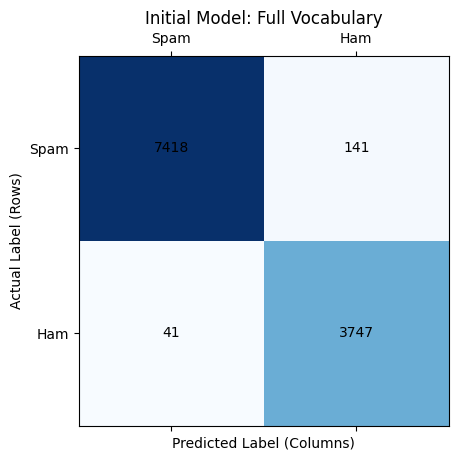


--- Lambda Smoothing ---

 Values based on given paper
  Lambda: 2.0 | F1: 0.9886 (Precision: 0.9931, Recall: 0.9841)
  Lambda: 1.0 | F1: 0.9879 (Precision: 0.9945, Recall: 0.9813)
  Lambda: 0.5 | F1: 0.9858 (Precision: 0.9962, Recall: 0.9757)
  Lambda: 0.1 | F1: 0.9722 (Precision: 0.9983, Recall: 0.9475)
  Lambda: 0.005 | F1: 0.9585 (Precision: 0.9997, Recall: 0.9205)
Best Lambda found: 2.0 (used F1 score instead of highest precision and highest recall)


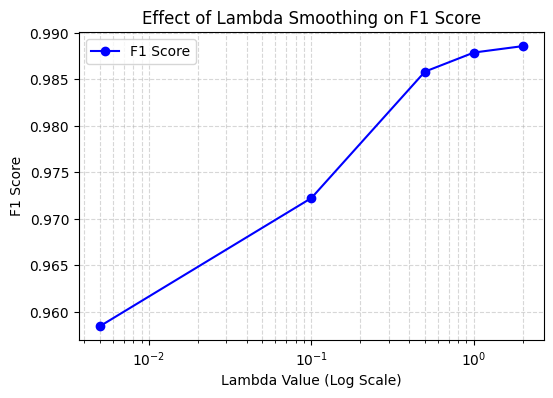


Evaluating Baseline Model (Best lambda)...
Baseline Results: Precision: 0.9931, Recall: 0.9841


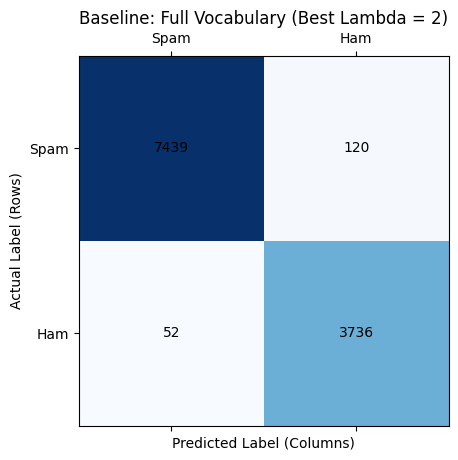


--- Improving (Hovold's Mutual Information) ---
Calculating Mutual Information for all words...
Selected Top 200 words.

--- Top 200 Most Informative Words (Hovold's MI) ---
Row 1: I , list , the , use , if , on , that , MIME , would , to , University , format , there , of , but
Row 2: it , Info , be , Thanks , with , have , anyone , my , PM , problem , work , DMDX , and , an , ASCII
Row 3: RIBBON , AGAINST , can , file , MAIL , know , campaign , as , so , just , apache , HB , running , which , other
Row 4: opt , am , CAMPAIGN , On , me , our , same , not , some , two , then , code , are , do , files
Row 5: board , does , Outlook , seems , should , PUBLIC , get , If , This , By , port , Express , IC , time , localhost
Row 6: Microsoft , Our , Department , input , about , sender , output , version , z , between , a , handyboard , you , need , AM
Row 7: question , what , Does , system , However , host , problems , any , Any , different , Handy , one , error , CREN , how
Row 8: for , thi

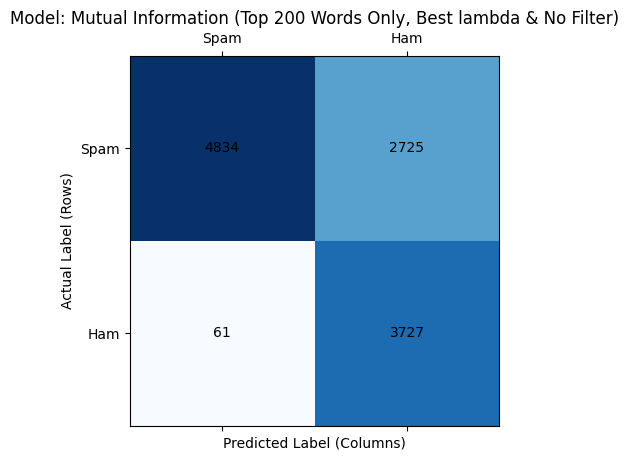


--- Improving (Hovold's Mutual Information) ---
Calculating Mutual Information for all words...
Selected Top 400 words.

--- Top 400 Most Informative Words (Hovold's MI) ---

--- Compares the results if the vocabulary size is increased ---
Row 1: I , list , the , use , if , on , that , MIME , would , to , University , format , there , of , but
Row 2: it , Info , be , Thanks , with , have , anyone , my , PM , problem , work , DMDX , and , an , ASCII
Row 3: RIBBON , AGAINST , can , file , MAIL , know , campaign , as , so , just , apache , HB , running , which , other
Row 4: opt , am , CAMPAIGN , On , me , our , same , not , some , two , then , code , are , do , files
Row 5: board , does , Outlook , seems , should , PUBLIC , get , If , This , By , port , Express , IC , time , localhost
Row 6: Microsoft , Our , Department , input , about , sender , output , version , z , between , a , handyboard , you , need , AM
Row 7: question , what , Does , system , However , host , problems , any , A

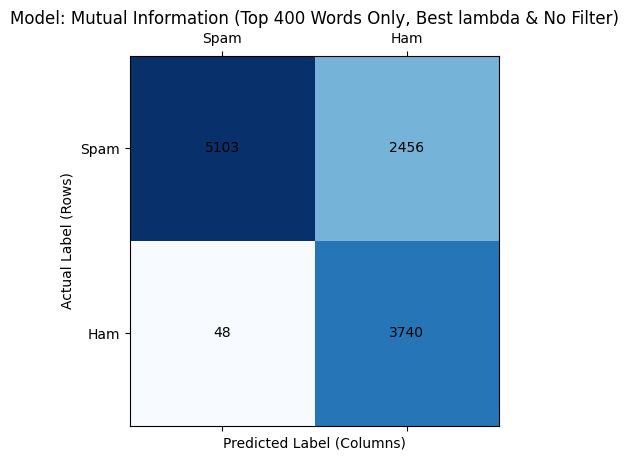


Removing the 200 most frequent words (Hovold's frequency filter)...
Removed top 200 words.

--- Improving (Hovold's Mutual Information) ---
Calculating Mutual Information for all words...
Selected Top 200 words.

--- Top 200 Most Informative Words with frequency filter (Hovold's MI) ---
Row 1: University , anyone , PM , DMDX , ASCII , RIBBON , AGAINST , file , MAIL , HB , running , CAMPAIGN , On , same , code
Row 2: files , board , seems , port , IC , Department , input , output , version , z , between , handyboard , AM , question , Does
Row 3: system , However , host , problems , Any , different , Handy , error , CREN , think , RO , Handyboard , probably , able , test
Row 4: motor , Mozilla , either , robot , mailing , tried , ra , point , item , machine , display , m , Discussion , send , messages
Row 5: Engineering , might , source , bit , web , working , seem , done , thanks , each , Mail , Computer , data , Version , itself
Row 6: v , page , correct , uses , Science , handy , put

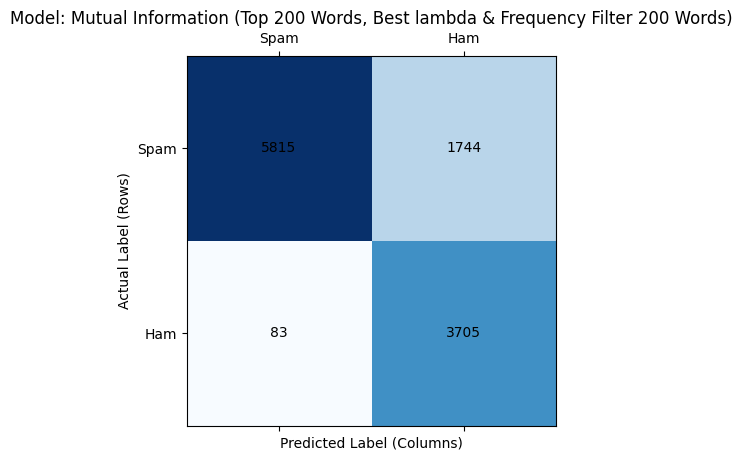


--- Use hovold's frequency filter ---

--- Improving (Hovold's Mutual Information) ---
Calculating Mutual Information for all words...
Selected Top 400 words.

--- Top 1000 Most Informative Words with frequency filter (Hovold's MI) ---
Row 1: University , anyone , PM , DMDX , ASCII , RIBBON , AGAINST , file , MAIL , HB , running , CAMPAIGN , On , same , code
Row 2: files , board , seems , port , IC , Department , input , output , version , z , between , handyboard , AM , question , Does
Row 3: system , However , host , problems , Any , different , Handy , error , CREN , think , RO , Handyboard , probably , able , test
Row 4: motor , Mozilla , either , robot , mailing , tried , ra , point , item , machine , display , m , Discussion , send , messages
Row 5: Engineering , might , source , bit , web , working , seem , done , thanks , each , Mail , Computer , data , Version , itself
Row 6: v , page , correct , uses , Science , handy , put , line , b , example , Also , GMT , something , som

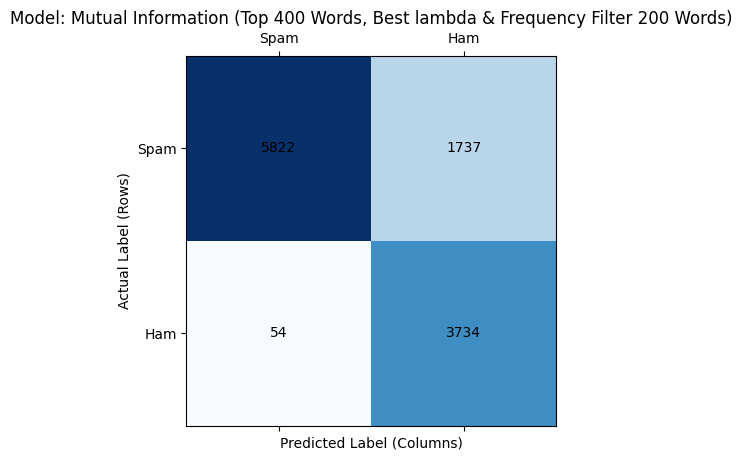

In [6]:
# 5. Main Function

def main():
    #  Write a script that makes disjoint training and test sets containing ham and spam. Use a 70-30 partitioning of your data. 
    print("Loading data...")
    all_data = get_data_paths(labels_location)

    # Randomize for training and test data
    random.seed(42) # For consistent results
    random.shuffle(all_data)

    split_index = int(len(all_data) * 0.70)
    train_set = all_data[:split_index]
    test_set = all_data[split_index:]

    
    ######################################################################################################################################
    # Training
    true_labels = []

    for item in test_set:
        label = item[1]
        true_labels.append(label)

    print("Training Initial Model...")
    nb = NaiveBayesClassifier(lamb=1.0) # declare object to use Class
    nb.train(train_set)

    
    #########################################################################################################################################
    print("\nEvaluating Initial Model (Before finding best lambda (default = 1) and hovold's mutual information)...")
    # Initial Model
    initial_preds = []
    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        initial_preds.append(prediction)

    precision, recall = calculate_precision_recall(initial_preds, true_labels)
    print(f"Initial Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(initial_preds, true_labels, title="Initial Model: Full Vocabulary")
    

    #########################################################################################################################################
    # Find Best Lambda
    best_lambda = lambda_smoothing(nb, test_set, true_labels)
    # Set the classifier to use the best lambda
    nb.lamb = best_lambda


    ##########################################################################################################################################
    # Baseline Model (Lambda = 2)
    print("\nEvaluating Baseline Model (Best lambda)...")

    baseline_preds = []

    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        baseline_preds.append(prediction)

    precision, recall = calculate_precision_recall(baseline_preds, true_labels)
    print(f"Baseline Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(baseline_preds, true_labels, title="Baseline: Full Vocabulary (Best Lambda = 2)")

    
    #############################################################################################################################################
    # Hovold's mutual information model
    top_features = nb.hovold_mutual_information(top_n=200)
    nb.set_selected_features(top_features)

    print("\n--- Top 200 Most Informative Words (Hovold's MI) ---")
    
    for index in range(0, len(top_features), 15):
        row = " , ".join(top_features[index:index+15])
        print(f"Row {index//15 + 1}: {row}")

    print("------------------------------------------------------------------")
    print("\nEvaluating Model (Best Lambda + Top 200 Features)...")
    final_preds = []
    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        final_preds.append(prediction)
    
    precision, recall = calculate_precision_recall(final_preds, true_labels)
    print(f"Final Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(final_preds, true_labels, title="Model: Mutual Information (Top 200 Words Only, Best lambda & No Filter)")


    ######################################################################################################################################
    # Hovold's mutual information model with a vocabulary of 400
    top_features = nb.hovold_mutual_information(top_n=400)
    nb.set_selected_features(top_features)

    print("\n--- Top 400 Most Informative Words (Hovold's MI) ---")
    print("\n--- Compares the results if the vocabulary size is increased ---")
    
    for index in range(0, len(top_features), 15):
        row = " , ".join(top_features[index:index+15])
        print(f"Row {index//15 + 1}: {row}")

    print("------------------------------------------------------------------")
    print("\nEvaluating Model (Best Lambda + Top 400 Features)...")
    final_preds = []
    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        final_preds.append(prediction)
    
    precision, recall = calculate_precision_recall(final_preds, true_labels)
    print(f"Final Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(final_preds, true_labels, title="Model: Mutual Information (Top 400 Words Only, Best lambda & No Filter)")

    
    #######################################################################################################################################
    # Hovold's mutual information model with a vocabulary of 200 and filter
    nb.remove_most_frequent_words(top_k=200)
    top_features = nb.hovold_mutual_information(top_n=200)

    # Filter top_features by removing most frequent words per Hovold's recommendation
    nb.set_selected_features(top_features)

    print("\n--- Top 200 Most Informative Words with frequency filter (Hovold's MI) ---")
    
    for index in range(0, len(top_features), 15):
        row = " , ".join(top_features[index:index+15])
        print(f"Row {index//15 + 1}: {row}")
        
    print("------------------------------------------------------------------")
    print("\nEvaluating Model (Best Lambda + Top 200 Features + Filter)...")
    final_preds = []
    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        final_preds.append(prediction)
    
    precision, recall = calculate_precision_recall(final_preds, true_labels)
    print(f"Final Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(final_preds, true_labels, title="Model: Mutual Information (Top 200 Words, Best lambda & Frequency Filter 200 Words)")


    ###############################################################################################################################################
    # Hovold's mutual information model with a vocabulary of 400 and filter
    print("\n--- Use hovold's frequency filter ---")
    top_features = nb.hovold_mutual_information(top_n=400)

    # Filter top_features by removing most frequent words per Hovold's recommendation
    nb.set_selected_features(top_features)

    print("\n--- Top 1000 Most Informative Words with frequency filter (Hovold's MI) ---")
    
    for index in range(0, len(top_features), 15):
        row = " , ".join(top_features[index:index+15])
        print(f"Row {index//15 + 1}: {row}")

    print("------------------------------------------------------------------")
    print("\nEvaluating Model (Best Lambda + Top 400 Features + Filter)...")
    final_preds = []
    for file_path, label in test_set:
        prediction = nb.classify(file_path)
        final_preds.append(prediction)
    
    precision, recall = calculate_precision_recall(final_preds, true_labels)
    print(f"Final Results: Precision: {precision:.4f}, Recall: {recall:.4f}")
    plot_confusion_matrix(final_preds, true_labels, title="Model: Mutual Information (Top 400 Words, Best lambda & Frequency Filter 200 Words)")

    
if __name__ == "__main__":
    main()
